# Trabajo práctico Nº1: Binarias Espectroscópicas

## Método de Lehmann-Filhés

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Para que todas las figuras tengan el mismo tamaño de fuentes es más facil definirlas de manera global
# Además formateo los ticks y el tamaño por defecto de la figura
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 8

plt.rc('font', family='serif', size=16, serif='STIXGeneral') # fuente por defecto
plt.rc('axes', titlesize=22)                                 # tamaño de fuente título de axe
plt.rc('axes', labelsize=18)                                 # tamaño de fuente nombre de ejes
plt.rc('xtick', labelsize=16, direction='in')                # tamaño de fuentes ticks
plt.rc('ytick', labelsize=16, direction='in')                # tamaño de fuentes ticks
plt.rc('legend', fontsize=16)                                # tamaño de fuentes referencia
plt.rc('figure', titlesize=24)                               # tamaño de fuente título de figura
plt.rc('mathtext', fontset='stix')
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.minor', top=False)
plt.rc('xtick.major', size=10)
plt.rc('xtick.minor', size=6)
plt.rc('ytick.major', size=10)
plt.rc('ytick.minor', size=6)

### Ejercicio 1a:
Descargar del Classroom la tabla de velocidad radial (Vr) vs. Fecha Juliana Heliocéntrica (HJD) correspondienteal sistema binario V501 Mon. Respresente gráficamente las observaciones de cada componente (Vr vs. HJD-2450000) incluyendo las correspondientes barras de error.

In [3]:
V501 = pd.read_csv ( 'V501Mon.dat', sep = '  ', comment = '#', names = ["HJD", "VR1", "err1", "VR2", "err2"])
#V501

<ipython-input-3-db2e27f5bdf1>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  V501 = pd.read_csv ( 'V501Mon.dat', sep = '  ', comment = '#', names = ["HJD", "VR1", "err1", "VR2", "err2"])


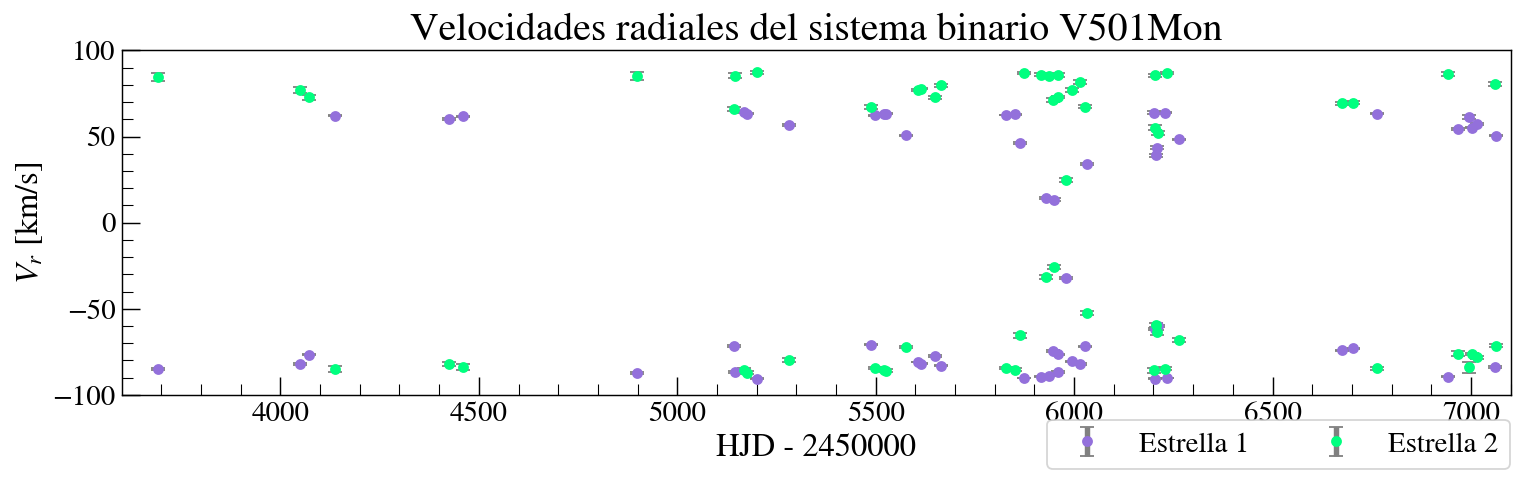

In [4]:
fig, ax = plt.subplots(figsize=(12,4), dpi=130)

HJD0 = V501.loc[:,'HJD'] - 2450000

ax.errorbar(HJD0, 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple',
            ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax.errorbar(HJD0, 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',
            ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')

ax.set_xlim(3600,7100)
ax.set_ylim(-100,100)
ax.set_xlabel('HJD - 2450000')
ax.set_ylabel('$V_r$ [km/s]')
ax.set_title('Velocidades radiales del sistema binario V501Mon')
plt.legend(bbox_to_anchor = (1.01,-0.03), ncol = 2)
fig.tight_layout()
plt.show()

### Ejercicio 1b:
Conociendo el período orbital $P=7,02120771±0,00000097$ días, y adaptando una fase inicial $φ_0=0$ para el instante $T_1=2453690,9255$, obtenga la fase φ correspondiente a cada observación. Represente en un gráfico Vr vs. φ para las dos componentes del sistema.

In [5]:
# Defino los parámetros para calcular la fase de la observación
P = 7.02120771
T1=2453690.9255

#Definición de fase:
V501['fase'] = (V501['HJD'] - T1)/P - np.floor((V501['HJD'] - T1)/P)
#La función floor es equivalente a la función máximo entero

V501

,HJD,VR1,err1,VR2,err2,fase
0,2.453691e+06,-84.96,0.64,84.73,2.32,0.000000
1,2.454049e+06,-82.16,0.47,76.84,1.72,0.991242
2,2.454071e+06,-76.65,0.39,72.80,1.40,0.129220
3,2.454137e+06,62.18,0.46,-85.06,1.66,0.514330
4,2.454425e+06,60.25,0.37,-82.04,1.32,0.540633
5,2.454460e+06,61.68,0.52,-83.79,1.89,0.521671
6,2.454899e+06,-87.35,0.64,84.93,2.32,0.021488
7,2.455144e+06,-71.58,0.47,65.89,1.21,0.949853
8,2.455145e+06,-86.62,0.57,85.43,1.46,0.090256
9,2.455169e+06,64.13,0.39,-85.34,0.99,0.496279


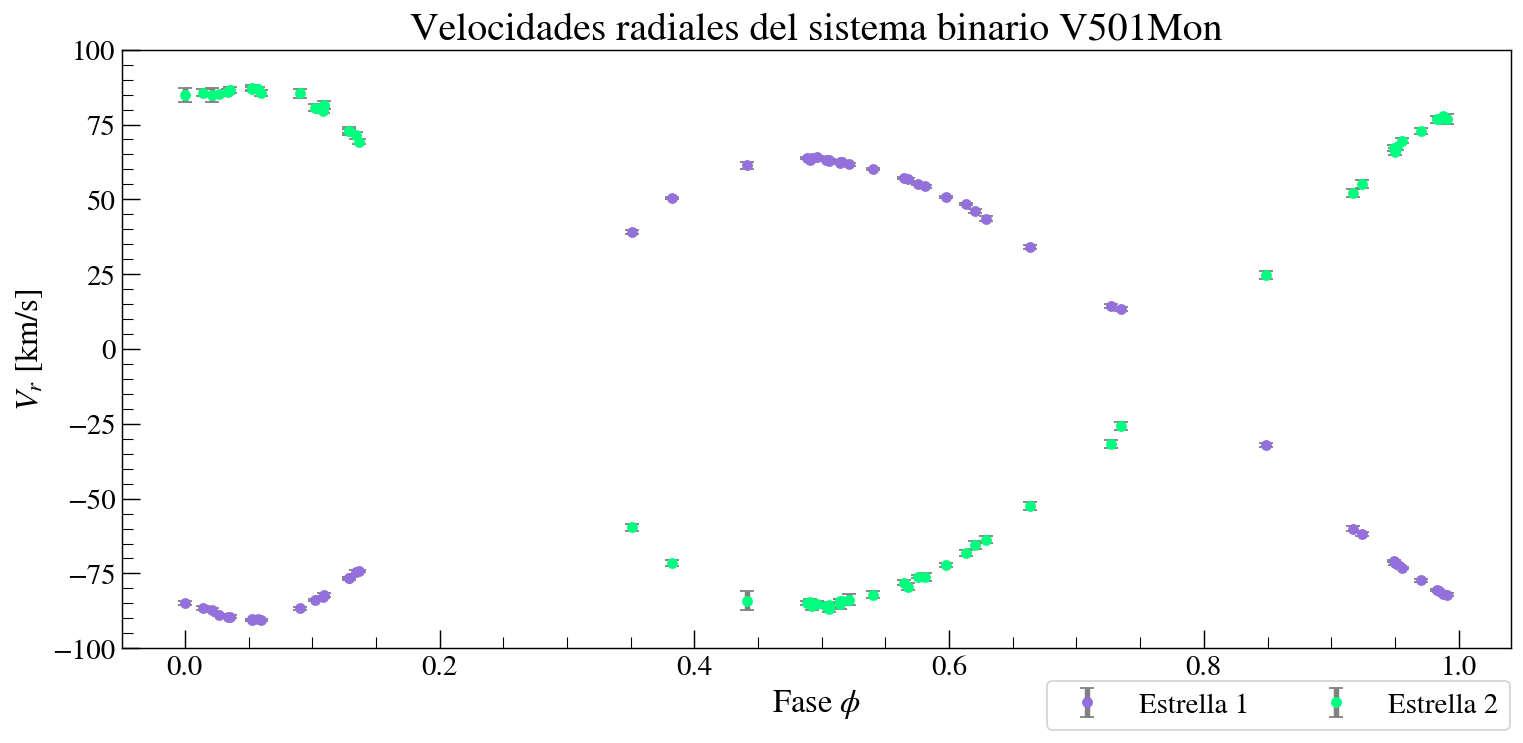

In [6]:
fig, ax = plt.subplots(figsize=(12,6), dpi=130)

ax.errorbar('fase', 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax.errorbar('fase', 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',  ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')

#ax.set_xlim(3600,7100)
ax.set_ylim(-100,100)
ax.set_xlabel('Fase $\phi$')
ax.set_ylabel('$V_r$ [km/s]')
ax.set_title('Velocidades radiales del sistema binario V501Mon')
plt.legend(bbox_to_anchor = (1.01,-0.03), ncol = 2)
fig.tight_layout()
plt.show()

### Ejercicio 1c:
Para poder aplicar el método de Lehmann-Filhés, usando solamente los datos de la componente primaria, ajuste una serie de Fourier a los datos ($\phi$, $V_r$ ). La serie de Fourier tiene esta forma

$s(x) = a_0 + \sum_{n=1}^N[a_n cos(2πnx) + b_n sin(2πnx)]$,

donde en nuestro caso x ≡ φ. Se sugiere probar con N = 1 y N = 2 y luego decidir cuál es el mejor ajuste. Grafique la serie $s(x)$ junto con los datos para mostrar la bondad del ajuste. Considere que esa serie representa la curva de velocidad radial en el intervalo $0 \leq \phi \leq 1$. 

In [7]:
# Importamos curve_fit que ajusta una función a los datos
from scipy.optimize import curve_fit

In [8]:
# Pruebo con un ajuste de primer grado (N=1)
# La serie de Fourier tendrá la forma:

def s0(x, a0, a1, b1):
    y = a0 + a1*np.cos(2*np.pi*x) + b1*np.sin(2*np.pi*x)
    return y

coefs, cov = curve_fit(s0, V501['fase'], V501['VR1'], sigma=V501['err1'])
coefs_err = np.sqrt(np.diag(cov))  # Las raices cuadradas de la diagonal son los errores del ajuste
print('Coeficientes:', coefs)
print('Errores de los coeficientes:',coefs_err)
print('Matriz de covarianza:')
print(cov)

fit_x0 = np.linspace(0,1,200) # Es una función muy similar a np.arrange()
fit_y0 = s0(fit_x0, coefs[0], coefs[1], coefs[2])

Coeficientes: [-12.09527587 -73.3809758  -15.62289486]
Errores de los coeficientes: [0.61758514 0.71524348 1.74669065]
Matriz de covarianza:
[[ 0.3814114  -0.05455824  0.00725921]
 [-0.05455824  0.51157323 -0.45279549]
 [ 0.00725921 -0.45279549  3.05092822]]


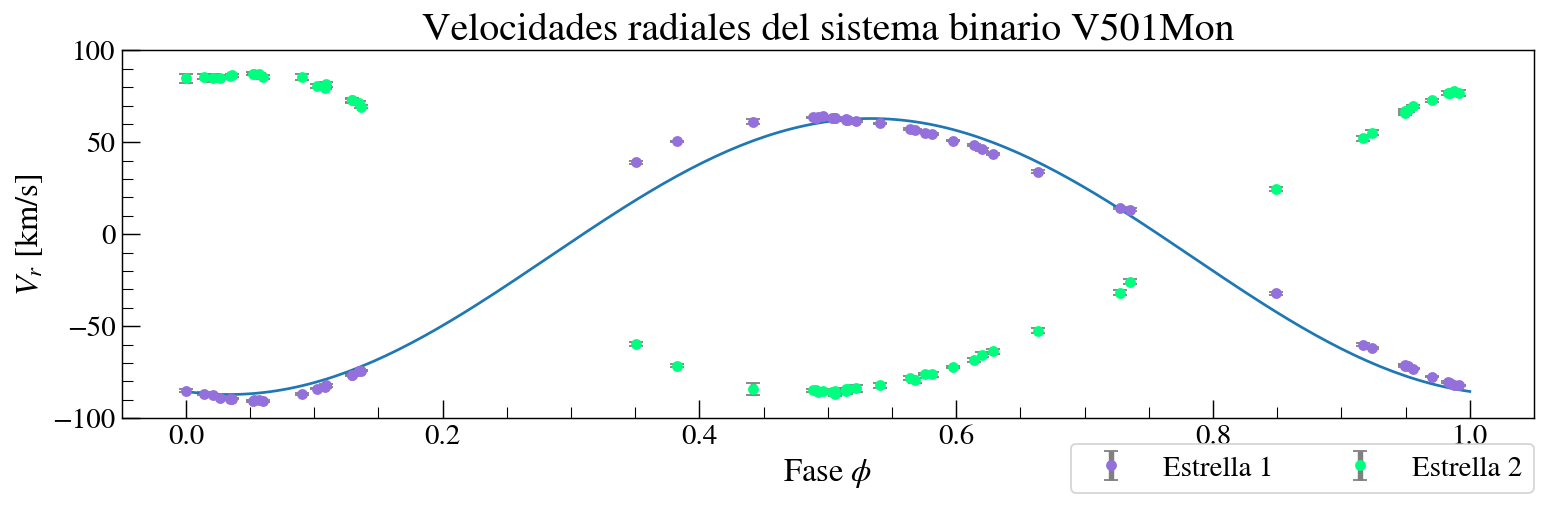

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12,4), dpi=130)

ax.errorbar('fase', 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax.errorbar('fase', 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',  ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')
ax.plot(fit_x0,fit_y0)

ax.set_ylim(-100,100)
ax.set_xlabel('Fase $\phi$')
ax.set_ylabel('$V_r$ [km/s]')
ax.set_title('Velocidades radiales del sistema binario V501Mon')
plt.legend(bbox_to_anchor = (1.01,-0.03), ncol = 2)
fig.tight_layout()
plt.show()

In [ ]:
# Pruebo con un ajuste de segundo grado (N=2)
# La serie de Fourier tendrá la forma:

def s(x, a0, a1, b1, a2, b2):
    y = a0 + a1*np.cos(2*np.pi*x) + b1*np.sin(2*np.pi*x) + a2*np.cos(2*np.pi*2*x) + b2*np.sin(2*np.pi*2*x)
    return y

coefs, cov = curve_fit(s, V501['fase'], V501['VR1'], sigma=V501['err1'])
coefs_err = np.sqrt(np.diag(cov))  # Las raices cuadradas de la diagonal son los errores del ajuste
print('Coeficientes:', coefs)
print('Errores de los coeficientes:',coefs_err)
print('Matriz de covarianza:')
print(cov)

fit_x = np.linspace(0,1,1000) # Es una función muy similar a np.arrange()
fit_y = s(fit_x, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])

Coeficientes: [ -6.90644132 -74.28213641 -12.33432891  -3.70275045  -9.74915625]
Errores de los coeficientes: [0.17743728 0.08204462 0.20580634 0.19877283 0.15225663]
Matriz de covarianza:
[[ 0.03148399 -0.00183451  0.00021182 -0.03162737 -0.01499998]
 [-0.00183451  0.00673132 -0.00649231  0.00082238  0.00210723]
 [ 0.00021182 -0.00649231  0.04235625  0.00240314 -0.00711374]
 [-0.03162737  0.00082238  0.00240314  0.03951064  0.0125099 ]
 [-0.01499998  0.00210723 -0.00711374  0.0125099   0.02318208]]


In [11]:
# Curvas de ajuste considerando los errores en las mediciones
# Para después graficar las curvas de error
# Aparentemente, son gráficamente irrelevantes

err_sup = s(fit_x, coefs[0] + coefs_err[0], coefs[1] + coefs_err[1], coefs[2] + coefs_err[2], coefs[3] + coefs_err[3], coefs[4] + coefs_err[4])
err_inf = s(fit_x, coefs[0] - coefs_err[0], coefs[1] - coefs_err[1], coefs[2] - coefs_err[2], coefs[3] - coefs_err[3], coefs[4] - coefs_err[4])

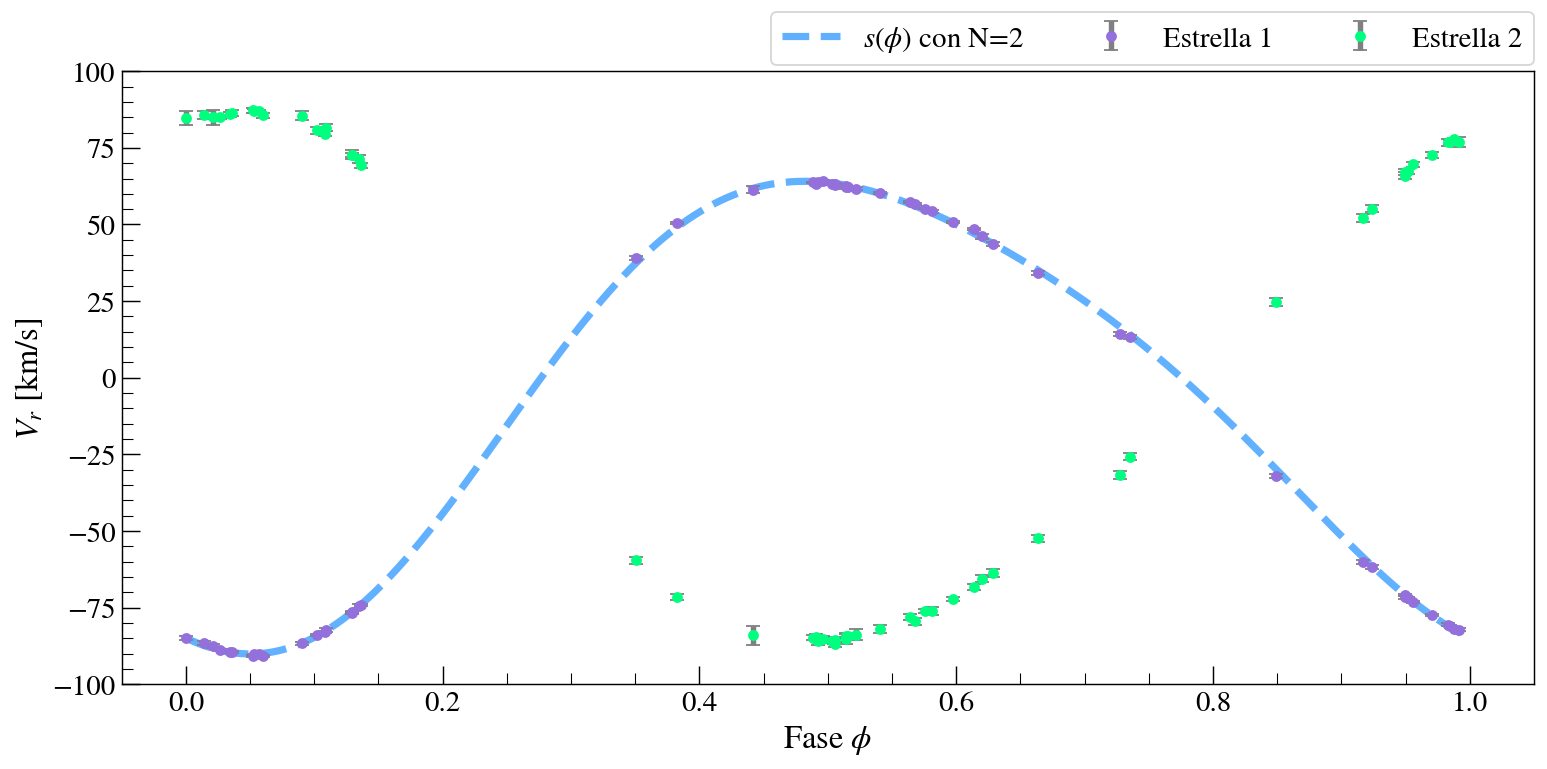

In [12]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12,6), dpi=130)

ax.plot(fit_x,fit_y, color='dodgerblue', linestyle = 'dashed', linewidth = 4, alpha=0.7, label='$s(\phi)$ con N=2')

ax.errorbar('fase', 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax.errorbar('fase', 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',  ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')

# Curvas de error: Son muy chicos aparentemente
#ax.fill_between(fit_x, err_inf, err_sup, color='grey', alpha=0.3)

ax.set_ylim(-100,100)
ax.set_xlabel('Fase $\phi$')
ax.set_ylabel('$V_r$ [km/s]')
#ax.set_title('Ajuste de la primera componente')
plt.legend(bbox_to_anchor = (1.01,1.12), ncol = 3)
fig.tight_layout()
plt.show()

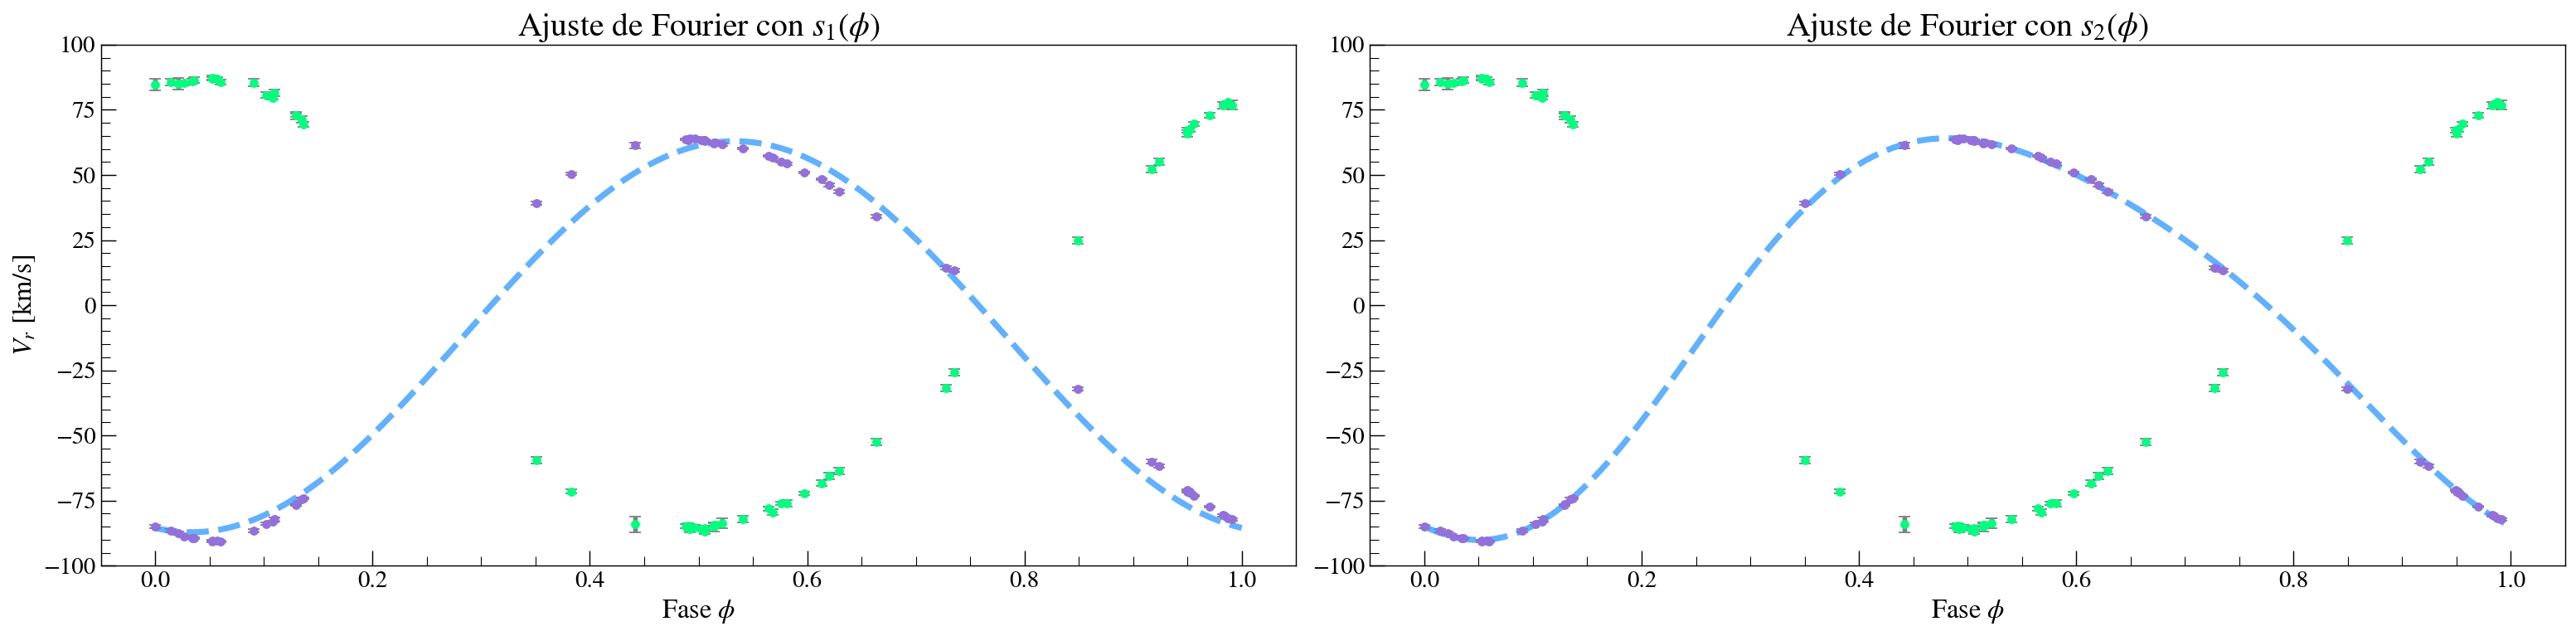

In [ ]:
# Gráficos lado a lado en modo comparativo
fig, (ax0, ax1) = plt.subplots ( ncols = 2, nrows = 1, figsize = (24, 6), dpi = 130 )

ax0.errorbar('fase', 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax0.errorbar('fase', 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',  ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')
ax0.plot(fit_x0,fit_y0, color='dodgerblue', linestyle = 'dashed', linewidth = 4, alpha=0.7, label='$s(\phi)$ con N=1')

ax0.set_ylim(-100,100)
ax0.set_xlabel('Fase $\phi$')
ax0.set_ylabel('$V_r$ [km/s]')
ax0.set_title('Ajuste de Fourier con $s_1(\phi)$')
###############################################################################################################################################################

ax1.errorbar('fase', 'VR1', yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax1.errorbar('fase', 'VR2', yerr='err2', data = V501, fmt='.', color='springgreen',  ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 2')
ax1.plot(fit_x,fit_y, color='dodgerblue', linestyle = 'dashed', linewidth = 4, alpha=0.7, label='$s(\phi)$ con N=2')

ax1.set_ylim(-100,100)
ax1.set_xlabel('Fase $\phi$')
ax1.set_title('Ajuste de Fourier con $s_2(\phi)$')

###############################################################################################################################################################

fig.tight_layout()
plt.show()

### Ejercicio 1d:
Recordando la condición que debe cumplir la velocidad baricentral $V_0$ del sistema con respecto a las áreas bajo la curva de velocidad radial, utilice la serie $s(x)$ para calcular $V_0$.

queda definido según:
$\int_t^{t+P}\frac{dz}{dt}dt = \int_t^{t+P}V_r-V_0d\phi = 0$ uso la condición de que las areas son iguales

$\int_t^{t+P}V_rd\phi = V_0$ que es cte por definición (es la vel radial del sistema binario como un todo, no cambia según la fase de la observación)


$\int_t^{t+P}V_rd\phi \approx \int_t^{t+P}s(\phi)d\phi$ haciendo uso del ajuste en serie de Fourier

$V_0=a_0$ porque el término $a_0$ es el único que no se anula al integrar sobre un período

inchequeable (lo chequeable está en el LaTeX xd)

In [14]:
print('V0 =', coefs[0], "[km/s]")

V0 = -6.906441321239476 [km/s]


### Ejercicio 1e:
Represente ahora gráficamente la curva de velocidad radial de la componente primaria en un sistema de referencia fijo en el baricentro del sistema con la serie $[s(x)-V_0]$ supuesta. Encuentre los puntos A, B, C, D y E. Esto se puede hacer gráficamente, con el zoom del graficador que esté utilizando.

Conociendo esos puntos y usando los coeficientes de $s(x)$ calcule las áreas $Z_1, Z_1', Z_2 y Z_2'$, y la correspondiente semiamplitud $K_1$. Verifique que se cumplan las hipótesis del método respecto a la igualdad de las áreas.

In [15]:
# Los coeficientes ya ajustan bien así que los fijo en la función
def s1(x):
    y = s(x, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4]) # (x, a0, a1, b1, a2, b2)
    return y

def ds(x):
    a1 = 2*np.pi*coefs[1]
    b1 = 2*np.pi*coefs[2]
    a2 = 4*np.pi*coefs[3]
    b2 = 4*np.pi*coefs[4]
    
    y = -a1*np.sin(2*np.pi*x) + b1*np.cos(2*np.pi*x) - a2*np.sin(4*np.pi*x) + b2*np.cos(4*np.pi*x)
    return y

# Puntos del eje horizontal medidos NUMERICAMENTE
from scipy.optimize import fsolve
a = fsolve(ds, 0.5)
b = fsolve(ds, 0.05)
c = fsolve(s1, -0.2)
d = fsolve(s1, 0.25)
e = fsolve(s1, 0.8)

print("A=", a[0])
print("B=", b[0])
print("C=", c[0])
print("D=", d[0])
print("E=", e[0])

A= 0.48194342245607935
B= 0.050287811293705666
C= -0.22448840117152083
D= 0.2766268077455727
E= 0.7755115988284791


In [16]:
# Puntos del eje horizontal medidos A OJO
A=0.481481   #
B=0.050050   #              En verdad no me interesa que estén o no errados estos valores
C=-0.189007  # =r0          A partir de ahora sólo tienen un uso gráfico
E=0.810992   # =r2
D=0.252928   # =r1

# Recortes del eje horizontal
fit_x = np.linspace(-0.2,1,1000)

Z1 = np.linspace(C,B,250)
Z2 = np.linspace(B,D,250)
Z3 = np.linspace(D,A,250)
Z4 = np.linspace(A,E,250)
Z11= np.linspace(E,1,250)

# Redefino las funciones que me interesan según estas regiones:
fit_y = s(fit_x, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])
y1 = s(Z1, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])
y2 = s(Z2, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])
y3 = s(Z3, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])
y4 = s(Z4, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])
y5 = s(Z11, coefs[0], coefs[1], coefs[2], coefs[3], coefs[4])

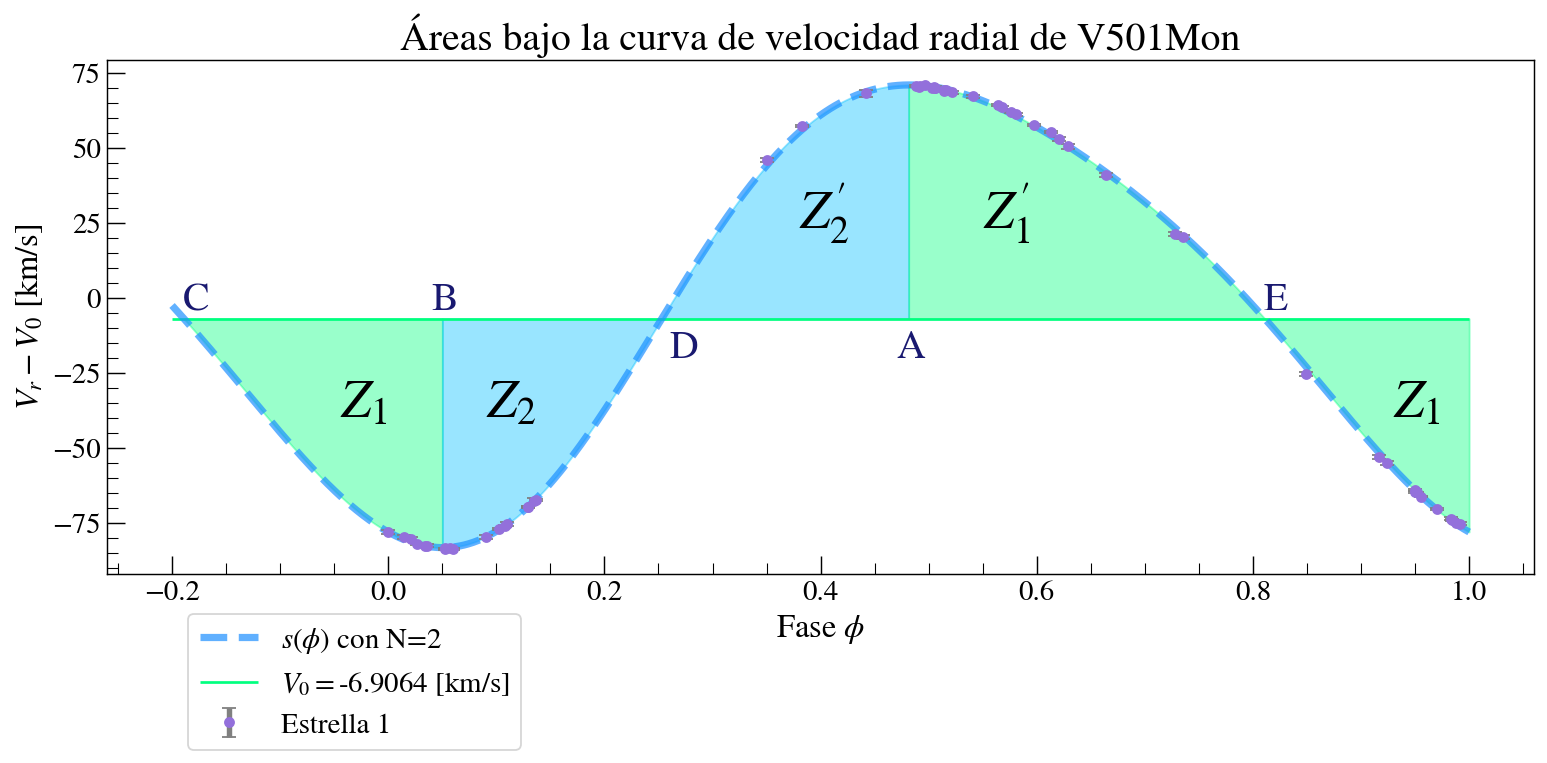

In [17]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12,6), dpi=130)

V0 = coefs[0] # = a0 [km/s]
V501['VR1bar'] = V501['VR1'] - V0

##### CURVAS Y DATOS ######

ax.plot(fit_x,fit_y - V0, color='dodgerblue', linestyle = 'dashed', linewidth = 4, alpha=0.7, label='$s(\phi)$ con N=2')
ax.errorbar('fase', 'VR1bar' , yerr='err1', data = V501, fmt='.', color='mediumpurple', ecolor='gray', elinewidth=3, markersize=10, capsize=4, label='Estrella 1')
ax.hlines(V0, -0.2, 1, color='springgreen', label='$V_0=$'+str(round(V0,4))+' [km/s]')
#ax.hlines(VR_T0, -0.2, 1, color='springgreen', label='$VR T0=$'+str(VR_T0))

##### AREAS SOMBREADAS ####

ax.fill_between(Z1 , V0, y1 - V0, color='springgreen', alpha=0.4)
ax.fill_between(Z2 , V0, y2 - V0, color='deepskyblue', alpha=0.4)
ax.fill_between(Z3 , V0, y3 - V0, color='deepskyblue', alpha=0.4)
ax.fill_between(Z4 , V0, y4 - V0, color='springgreen', alpha=0.4)
ax.fill_between(Z11, V0, y5 - V0, color='springgreen', alpha=0.4)

##### TEXTO ###############

ax.annotate(str('$Z_1$'), color = "black", xy = (-0.045,-40), size = 30)
ax.annotate(str("$Z_1'$"), color = "black", xy = (0.55,23), size = 30)
ax.annotate(str('$Z_2$'), color = "black", xy = (0.09,-40), size = 30)
ax.annotate(str("$Z_2'$"), color = "black", xy = (0.38,23), size = 30)
ax.annotate(str('$Z_1$'), color = "black", xy = (0.93,-40), size = 30)

ax.annotate(str('A'), color = "midnightblue", xy = (0.47,-20), size = 22)
ax.annotate(str('B'), color = "midnightblue", xy = (0.04, -4), size = 22)
ax.annotate(str('C'), color = "midnightblue", xy = (-0.19,-4), size = 22)
ax.annotate(str('D'), color = "midnightblue", xy = (0.26,-20), size = 22)
ax.annotate(str('E'), color = "midnightblue", xy = (0.81, -4), size = 22)

###########################

ax.set_xlabel('Fase $\phi$')
ax.set_ylabel('$V_r - V_0$ [km/s]')
ax.set_title('Áreas bajo la curva de velocidad radial de V501Mon')
plt.legend(bbox_to_anchor = (0.3,-0.05), ncol = 1)
fig.tight_layout()
plt.show()

In [ ]:
# Para hallar el valor de las áreas:
from scipy.integrate import quad

def vbar(x):        # Defino esta función porque es lo que debería haber hecho en el gráfico.
    y = s1(x)- V0   # hacer s1 - V0 "centra" la función de ajuste en V0, permitiéndome integrar correctamente
    return y        # las áreas sombreadas arriba

AZ1,  err1  = quad(vbar,c,b)
AZ2,  err2  = quad(vbar,b,d)
AZ21, err21 = quad(vbar,d,a)
AZ11, err11 = quad(vbar,a,e)

# Para hallar la semiamplitud:
K = (s1(a)[0]-s1(b)[0])/2.

print ('Las areas valen:')
print ("Z_1 =", -AZ1, "±", err1)   # −14.331382
print ("Z_1' =", AZ11, "±", err11) # 11.568047
print ("Z_2 =", -AZ2, "±", err2)   # −12.686064
print ("Z_2' =", AZ21, "±", err21) # 8.542972
print ()
print ('VRmin=', vbar(b), "[km/s]")
print ('VRmax=', vbar(a), "[km/s]")
print ("Y la semiamplitud K=", K, "[km/s]")

Las areas valen:
Z_1 = 12.696513678551108 ± 1.4230127862011525e-13
Z_1' = 13.807342238093305 ± 1.5329229261610629e-13
Z_2 = 11.264408351848829 ± 1.2600316735525174e-13
Z_2' = 10.153579792306639 ± 1.1272738067787545e-13

VRmin= [-83.18420432] [km/s]
VRmax= [70.99358824] [km/s]
Y la semiamplitud K= 77.08889627742678 [km/s]


### Ejercicio 1f:
Utilice las expresiones deducidas en la teoría para obtener:

 ·La excentricidad $e$ y el argumento del periastro $\omega_1$ (para el cálculo de $e \sin \omega_1$ use los promedios de $Z_1$ y $Z_1'$ y de $Z_2$ y $Z_2'$;
    
 · El semieje proyectado de la órbita de la componente primaria $a_1 sen i$ (preste especial atención a las unidades en este cálculo);
    
 · El instante de paso por el periastro $T_0$.

In [ ]:
#### Cálculo de la excentricidad #####################################################
# tomo las ecuaciones: e cos(omega) = (alpha-beta)/(alpha+beta)
#                      e sin(omega) = 2sqrt(alpha*beta)/(alpha+beta) * (Z2-Z1)/(Z2+Z1)

alpha =  vbar(a)[0]
beta  = -vbar(b)[0]   # Debe ser positiva
z_1 = (AZ11-AZ1)/2    # Utilizo los promedios de las áreas
z_2 = (AZ21-AZ2)/2

ecosw = (alpha-beta)/(alpha+beta)
esinw = 2*((np.sqrt(alpha*beta))/(alpha+beta))* ((z_2-z_1)/(z_2+z_1))

# Elevo al cuadrado y sumo: obtengo e^2

e = np.sqrt(ecosw**2+esinw**2)

#####################################################################################
#### Cálculo del argumento (o longitud) del periastro w1 ####
# Divido esinw por ecosw para obtener la tangente tg w1
# alpha-beta < 0 ; Z2 - Z1 < 0 --> creo que está en el 3er cuadrante

w1 = np.arctan(esinw/ecosw) + np.pi

print("e cos w1 =", ecosw)
print("e sin w1 =", esinw)
print("e =", e)
print("w1 =", w1, "[rad]")

e cos w1 = -0.07906856026568043
e sin w1 = -0.10579611317573794
e = 0.13207821465170208
w1 = 4.070574900744392 [rad]


In [20]:
#### Cálculo del semieje proyectado ########################################
# Partimos de la relación:
#a1 sen i = KP/2pi * sqrt(1-e**2)

# Tenemos ya como datos K[km/s], P[días], e[scalar]
asini = (K*P*86400/(2*np.pi)) * np.sqrt(1-e**2)

print("a1 sin i =", asini, "[km]")

a1 sin i = 7377615.786496753 [km]


In [21]:
#### Cálculo del instante de pasaje por el periastro #######################
# Corresponde a la condición v=0 (anomalía verdadera)

VR_T0 = V0 + K*(1+e)*np.cos(w1)

print("VR_T0 =",VR_T0,"[km/s]") #VR a la que se anula la anomalía verdadera

# Tengo que definir en qué instante estoy en el periastro, pues este valor
# de VR ocurre en dos momentos de la órbita. Para ello evalúo los valores
# de la anomalía verdadera v en A y en B, para saber en qué intervalo
# debe anularse.
# Teniendo en mente que w1 = 4.0705 rad
# En B: w+v=pi -> vb= -0.92 rad <0 LO PIENSO COMO ANTES DE PASAR POR EL PERIASTRO
# En A: w+v=0 -> va= -4.07 rad (+2PI) = 2.21 rad >0 LO PIENSO COMO DESPUÉS DE PASAR POR EL PERIASTRO
# En B+2pi: w+v=3pi -> vb=  5.35 rad >0

# Por lo tanto el tiempo de pasaje por el periastro deberá ser en el
# instante en que pasa entre C y B

def cuca(x):
    y = s1(x) - VR_T0
    return y

T0 = fsolve(cuca, 0.2)
print("T0=", T0[0])

TLucia = fsolve(cuca, 0)
print("Pero el que dice Lucía es T=", TLucia[0], "(O bien T=",TLucia[0]+1,")")

VR_T0 = -59.15098038581816 [km/s]
T0= 0.17124858430623013
Pero el que dice Lucía es T= -0.08165456507833263 (O bien T= 0.9183454349216673 )


### Ejercicio 3:
Usando las propiedades de la descripción del sistema binario en el marco de referencia de su centro de masa2, obtengael cociente de masas $\mu=\frac{M_2}{M1}$. Luego, utilizando $\mu$ y los resultados del ejercicio 1, obtenga $K_2$, $a_2 \sin i$ y las masas mínimas de las estrellas componentes del sistema. Compare sus resultados con los del artículo de Torres et al. (2015). Calcule las diferencias en los distintos parámetros en valores absolutos y relativos e indique si en su opinión ambos conjuntos de resultados son compatibles.

In [ ]:
# Ajuste lineal a las observaciones de las velocidades radiales

def f(vr,mu,gamma):
    v = mu*(vr) + gamma*(1+mu)
    return v

# Podría considerar los errores err1 y err2 con scipy.ODR
coe, cov = curve_fit(f,-V501['VR2'] , V501['VR1'], sigma=V501['err1'])

print('coeficientes',coe)
print('errores:', np.sqrt(np.diag(cov)) )

v1 = np.linspace(-90,90,90)
v2 = f(v1, coe[0], coe[1])

coeficientes [ 0.88794663 -6.6619841 ]
errores: [0.00133086 0.05666871]


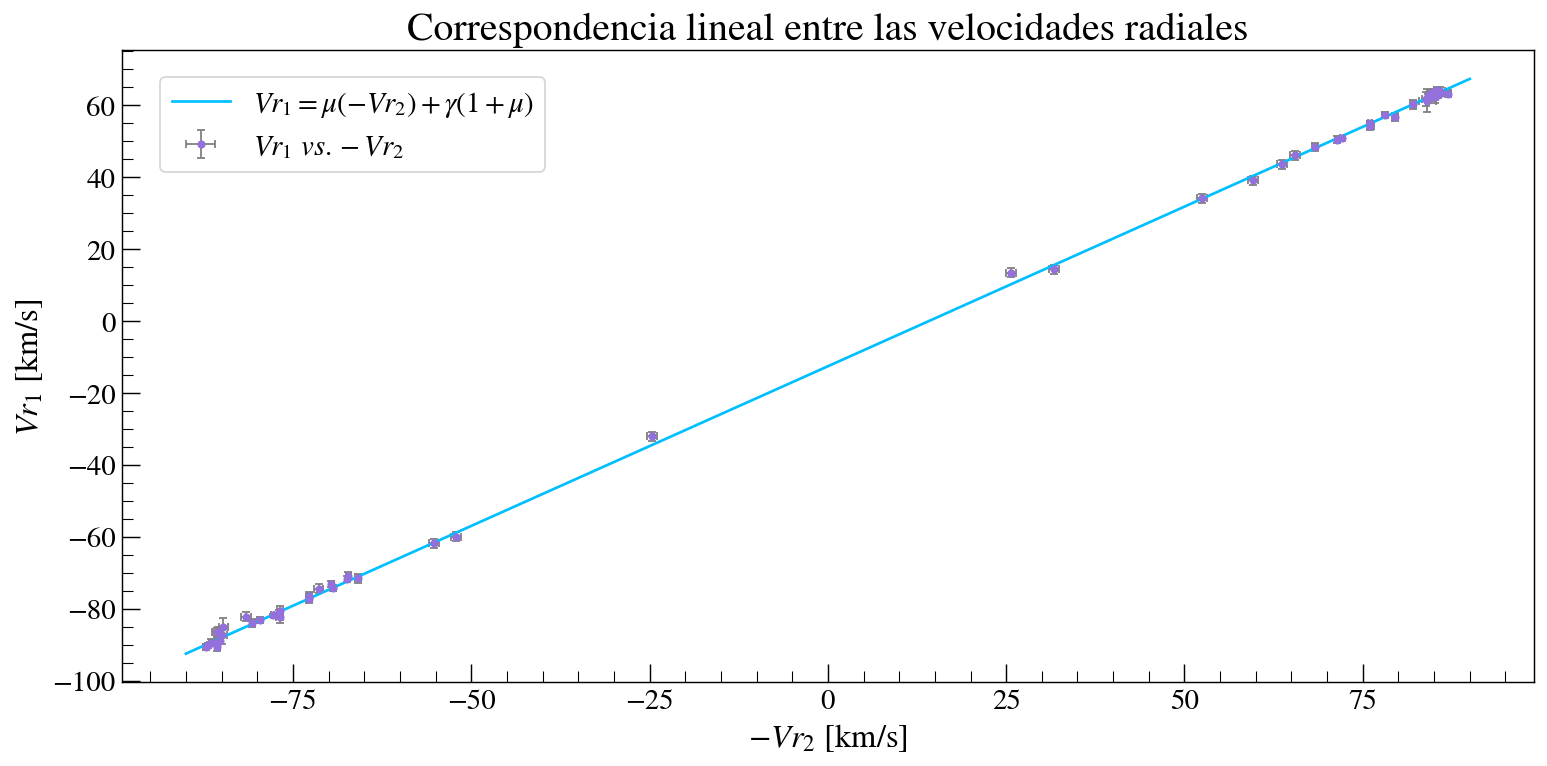

In [36]:
fig, ax = plt.subplots(figsize=(12,6), dpi=130)

ax.errorbar(-V501['VR2'], V501['VR1'], xerr = V501['err1'], yerr=V501['err2'], fmt='.', color='mediumpurple', ecolor='gray', elinewidth=1, markersize=7, capsize=2, label='$Vr_1~vs.-Vr_2$')
ax.plot(v1, v2, color='deepskyblue', label = '$Vr_1 = \mu(-Vr_2)+\gamma(1+\mu)$')

ax.set_xlabel('$-Vr_2$ [km/s]')
ax.set_ylabel('$Vr_1$ [km/s]')
ax.set_title('Correspondencia lineal entre las velocidades radiales')
plt.legend(bbox_to_anchor = (0.31,0.98), ncol=1)
fig.tight_layout()
plt.show()

In [ ]:
mu = coe[0]    # cociente de masas m2/m1
gamma = coe[1] # velovidad baricentral o sistémica

#k1/mu =k2  , semieje mayor primaria/mu = semieje mayor secundaria. 
#Masas mínimas: usar la fórmula de la teoría

K2 = np.abs(K/mu) # [km/s] relación entre las semiamplitudes
a2sini = (K2*P*86400/(2*np.pi)) * np.sqrt(1-e**2) # [km] semieje mayor proyectado

# MASAS MÍNIMAS
# Necesito pasar el período a AÑOS y los semiejes en UA's para obtener las masas en MASAS SOLARES
# (esto surge de la ley de Kepler adaptada a unidades)

M1 = ( (a2sini/149597870.7) / (P/365)**2 ) * ((asini + a2sini)/149597870.7)**2    # P años = 0.01923618550685
M2 = ( (asini/149597870.7) / (P/365)**2 ) * ((asini + a2sini)/149597870.7)**2

print('mu =', mu)
print('gamma =', gamma)
print('K2 =', K2, "[km/s]")
print('a2sini =', a2sini, "[km]")
print('Masas mínimas:')
print('M1 =', M1, "Msol")
print('M2 =', M2, "Msol")

mu = 0.8879466315381765
gamma = -6.661984102838036
K2 = 86.81703780314686 [km/s]
a2sini = 8308625.23090675 [km]
Masas mínimas:
M1 = 1.650261576536084 Msol
M2 = 1.4653442080420966 Msol
